# Baseline Model — Per-Star Summary Statistics

Instead of feeding raw observation sequences into a Transformer, compute summary statistics per star and train a simple Logistic Regression / Random Forest.

This answers: **is the 0.68 AUC ceiling a data problem or a model problem?**

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, confusion_matrix, average_precision_score
import matplotlib.pyplot as plt

observations = pd.DataFrame(pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'))

print(f"Total observations: {len(observations)}")
print(f"Stars: {observations['star_name'].nunique()}")
print(f"Columns: {list(observations.columns)}")

Total observations: 235567
Stars: 2187
Columns: ['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']


## Compute per-star summary statistics

In [11]:
def compute_star_features(group):
    """Compute summary statistics for one star from its observation sequence."""
    features = {}

    # -- RV statistics --
    features['rv_std'] = group['rv_centered'].std()
    features['rv_range'] = group['rv_centered'].max() - group['rv_centered'].min()
    features['rv_mean_abs_dev'] = (group['rv_centered'] - group['rv_centered'].median()).abs().mean()
    features['rv_skew'] = group['rv_centered'].skew()
    features['rv_kurtosis'] = group['rv_centered'].kurtosis()

    # -- RV error statistics --
    features['rv_err_mean'] = group['rv_err'].mean()
    features['rv_err_std'] = group['rv_err'].std()

    # -- Activity indicator statistics --
    features['rhkp_std'] = group['RHKp'].std()
    features['rhkp_range'] = group['RHKp'].max() - group['RHKp'].min()
    features['rhkp_mean'] = group['RHKp'].mean()
    features['halpha_std'] = group['Halpha'].std()
    features['halpha_range'] = group['Halpha'].max() - group['Halpha'].min()
    features['halpha_mean'] = group['Halpha'].mean()

    # -- RV-activity correlations --
    features['rv_rhkp_corr'] = group['rv_centered'].corr(group['RHKp'])
    features['rv_halpha_corr'] = group['rv_centered'].corr(group['Halpha'])
    features['rhkp_halpha_corr'] = group['RHKp'].corr(group['Halpha'])

    # -- Observation metadata --
    features['n_obs'] = len(group)
    features['time_baseline'] = group['bjd'].max() - group['bjd'].min()
    features['mean_exposure_time'] = group['exposure_time'].mean()

    # -- Label --
    features['has_exoplanets'] = group['has_exoplanets'].iloc[0]

    return pd.Series(features)

# Group by star and compute features
star_features = observations.groupby('star_name').apply(compute_star_features).reset_index()

# Handle NaN correlations (stars with zero variance in an activity index)
star_features = star_features.fillna(0)

print(f"Stars: {len(star_features)}")
print(f"Positive: {star_features['has_exoplanets'].sum()}")
print(f"Negative: {(star_features['has_exoplanets'] == 0).sum()}")
feature_cols = [c for c in star_features.columns if c not in ['star_name', 'has_exoplanets']]
print(f"Features: {feature_cols}")
print(f"Feature count: {len(feature_cols)}")
star_features.head()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Stars: 2187
Positive: 413.0
Negative: 1774
Features: ['rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis', 'rv_err_mean', 'rv_err_std', 'rhkp_std', 'rhkp_range', 'rhkp_mean', 'halpha_std', 'halpha_range', 'halpha_mean', 'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr', 'n_obs', 'time_baseline', 'mean_exposure_time']
Feature count: 19


/tmp/ipykernel_9397/1050067459.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star_features = observations.groupby('star_name').apply(compute_star_features).reset_index()


,star_name,rv_std,rv_range,rv_mean_abs_dev,rv_skew,rv_kurtosis,rv_err_mean,rv_err_std,rhkp_std,rhkp_range,...,halpha_std,halpha_range,halpha_mean,rv_rhkp_corr,rv_halpha_corr,rhkp_halpha_corr,n_obs,time_baseline,mean_exposure_time,has_exoplanets
0,0748-01711-1,65.449158,253.430000,48.394762,0.939032,0.520401,1.108095,0.150220,0.008072,0.032300,...,0.224187,1.027970,-0.021568,0.239633,-0.065713,-0.213394,21.0,1450.951650,476.714286,0.0
1,BD+01316,30.543037,112.167623,26.268566,0.115193,-1.011650,2.296750,0.709906,0.000019,0.000139,...,0.002970,0.012556,0.382815,-0.174212,0.333759,-0.273460,52.0,9.205498,600.000000,0.0
2,BD+062168,50.062829,255.335597,16.605952,-4.573733,21.549204,2.153173,0.211496,0.000005,0.000023,...,0.002882,0.009466,0.398398,-0.060291,-0.223847,0.238575,23.0,370.992797,1191.434783,0.0
3,BD+101799,8.674877,82.980462,3.977347,-4.835886,31.591498,2.675072,3.370410,0.000214,0.002358,...,0.004413,0.040853,0.386712,0.166024,-0.539411,0.238689,122.0,189.638355,892.614754,0.0
4,BD+144559,51.050810,128.615225,39.396802,0.612317,-1.545070,1.636196,0.122338,0.000006,0.000020,...,0.003157,0.011975,0.550990,-0.339822,0.249844,-0.649482,24.0,1119.888707,604.166667,1.0


## Train / Test Split + Standardization

In [12]:
seed = 42

X = star_features[feature_cols].values
y = star_features['has_exoplanets'].values

# Split FIRST, then standardize on training data only
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)

# Standardize using training stats only
mean = X_train.mean(axis=0)
std = np.clip(X_train.std(axis=0), 1e-8, None)
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print(f"Train: {len(X_train)} (pos={y_train.sum()}, neg={(1-y_train).sum()})")
print(f"Val:   {len(X_val)} (pos={y_val.sum()}, neg={(1-y_val).sum()})")
print(f"Test:  {len(X_test)} (pos={y_test.sum()}, neg={(1-y_test).sum()})")

Train: 1312 (pos=248.0, neg=1064.0)
Val:   437 (pos=82.0, neg=355.0)
Test:  438 (pos=83.0, neg=355.0)


## Logistic Regression

In [13]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

# Feature importances (coefficients)
print("\nFeature coefficients (sorted by absolute value):")
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': lr.coef_[0]})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
for _, row in coef_df.iterrows():
    direction = "->planet" if row['coefficient'] > 0 else "->no planet"
    print(f"  {row['feature']:25s} {row['coefficient']:+.4f} {direction}")

Logistic Regression ROC-AUC: 0.6753

Feature coefficients (sorted by absolute value):
  rv_mean_abs_dev           -1.2061 ->no planet
  rhkp_mean                 -0.7647 ->no planet
  rhkp_range                +0.6931 ->planet
  halpha_std                -0.6058 ->no planet
  rv_std                    +0.5765 ->planet
  halpha_range              +0.3271 ->planet
  rhkp_std                  -0.2707 ->no planet
  rv_range                  +0.2695 ->planet
  mean_exposure_time        +0.2028 ->planet
  time_baseline             +0.1681 ->planet
  rv_err_mean               -0.1324 ->no planet
  n_obs                     +0.1269 ->planet
  rv_err_std                -0.1177 ->no planet
  rhkp_halpha_corr          -0.1028 ->no planet
  rv_kurtosis               -0.1023 ->no planet
  rv_skew                   +0.0810 ->planet
  rv_rhkp_corr              -0.0631 ->no planet
  rv_halpha_corr            +0.0504 ->planet
  halpha_mean               +0.0155 ->planet


## Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=seed, max_depth=None)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

# Feature importances
print("\nFeature importances (sorted):")
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False)
for _, row in imp_df.iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

Random Forest ROC-AUC: 0.8150

Feature importances (sorted):
  n_obs                     0.0934
  rv_range                  0.0909
  rv_mean_abs_dev           0.0817
  rv_std                    0.0780
  rv_kurtosis               0.0609
  mean_exposure_time        0.0534
  halpha_mean               0.0502
  rv_err_mean               0.0484
  rv_rhkp_corr              0.0463
  rhkp_mean                 0.0445
  rhkp_range                0.0433
  rv_halpha_corr            0.0424
  time_baseline             0.0417
  halpha_range              0.0415
  rhkp_std                  0.0396
  rhkp_halpha_corr          0.0385
  rv_skew                   0.0369
  rv_err_std                0.0360
  halpha_std                0.0324


## Best Model — Detailed Evaluation

In [15]:
# Pick the better model
if lr_auc >= rf_auc:
    best_name = "Logistic Regression"
    best_probs = lr_probs
    best_auc = lr_auc
else:
    best_name = "Random Forest"
    best_probs = rf_probs
    best_auc = rf_auc

print(f"Best baseline model: {best_name} (AUC = {best_auc:.4f})")
print(f"Transformer AUC for reference: 0.6793")
print(f"Difference: {best_auc - 0.6793:+.4f}")

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, best_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]


# PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, best_probs)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"ROC-AUC:                    {best_auc:.4f}")

print(f"\nBest F1 threshold: {best_threshold:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

# Classification reports
print("=" * 60)
print("REPORT AT DEFAULT THRESHOLD (0.5)")
print("=" * 60)
preds_05 = (best_probs >= 0.5).astype(int)
print(classification_report(y_test, preds_05, target_names=['No Planet', 'Planet']))

print("=" * 60)
print(f"REPORT AT OPTIMAL THRESHOLD ({best_threshold:.4f})")
print("=" * 60)
preds_opt = (best_probs >= best_threshold).astype(int)
print(classification_report(y_test, preds_opt, target_names=['No Planet', 'Planet']))

Best baseline model: Random Forest (AUC = 0.8150)
Transformer AUC for reference: 0.6793
Difference: +0.1357
PR-AUC (Average Precision): 0.5645
ROC-AUC:                    0.8150

Best F1 threshold: 0.2800
  Precision: 0.5258
  Recall:    0.6145
  F1:        0.5667
REPORT AT DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

   No Planet       0.85      0.97      0.90       355
      Planet       0.66      0.25      0.37        83

    accuracy                           0.83       438
   macro avg       0.75      0.61      0.63       438
weighted avg       0.81      0.83      0.80       438

REPORT AT OPTIMAL THRESHOLD (0.2800)
              precision    recall  f1-score   support

   No Planet       0.91      0.87      0.89       355
      Planet       0.53      0.61      0.57        83

    accuracy                           0.82       438
   macro avg       0.72      0.74      0.73       438
weighted avg       0.83      0.82      0.83       438



## Confusion Matrix at Optimal Threshold

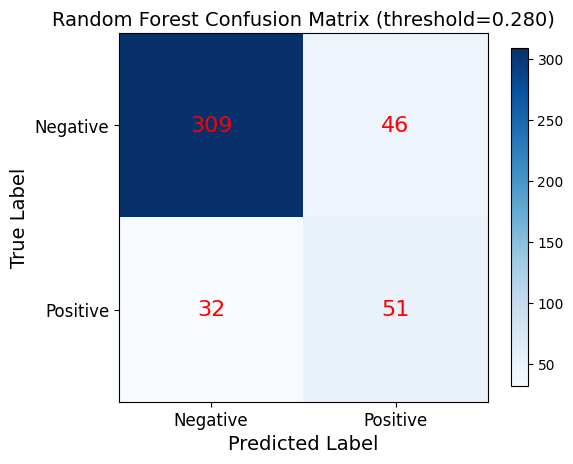

In [16]:
preds = (best_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

classes = ['Negative', 'Positive']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title(f'{best_name} Confusion Matrix (threshold={best_threshold:.3f})', fontsize=14)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

## Ablation: Remove Observational Proxies

`n_obs`, `time_baseline`, and `mean_exposure_time` are **observational metadata**, not planet detection signals. Stars targeted for follow-up are more likely to be planet hosts — the model may be learning "did astronomers think this star was interesting" rather than "does this star have a planet."

This ablation removes those 3 features and re-trains the RF on the 16 purely physical features (RV statistics, error statistics, activity indicators, and their correlations). The AUC drop tells us how much of the full model's performance was real physical signal vs observational selection bias.

In [17]:
physical_features = [
    'rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis',
    'rv_err_mean', 'rv_err_std',
    'rhkp_std', 'rhkp_range', 'rhkp_mean',
    'halpha_std', 'halpha_range', 'halpha_mean',
    'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr'
]

removed = [c for c in feature_cols if c not in physical_features]
print(f"Features WITH observational proxies (19): {feature_cols}")
print(f"Features WITHOUT observational proxies (16): {physical_features}")
print(f"Removed: {removed}")
print()

# Re-index into the physical features only
physical_idx = [feature_cols.index(c) for c in physical_features]
X_train_phys = X_train[:, physical_idx]
X_val_phys   = X_val[:, physical_idx]
X_test_phys  = X_test[:, physical_idx]

# Re-train RF on physical features only (same train set as full model)
rf_phys = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=seed, max_depth=None)
rf_phys.fit(X_train_phys, y_train)

rf_phys_probs = rf_phys.predict_proba(X_test_phys)[:, 1]
rf_phys_auc = roc_auc_score(y_test, rf_phys_probs)

print("=" * 60)
print("ABLATION: RF WITHOUT OBSERVATIONAL PROXIES")
print("=" * 60)
print(f"Features used: {len(physical_features)} (physical only)")
print(f"ROC-AUC:                   {rf_phys_auc:.4f}")
print(f"Full RF AUC (19 features): {rf_auc:.4f}")
pr_phys_auc = average_precision_score(y_test, rf_phys_probs)
print(f"PR-AUC:                    {pr_phys_auc:.4f}")
print(f"Full RF PR-AUC (19 feats): {average_precision_score(y_test, rf_probs):.4f}")

print(f"Drop from removing proxies: {rf_auc - rf_phys_auc:.4f}")

# Optimal threshold
prec_phys, rec_phys, thr_phys = precision_recall_curve(y_test, rf_phys_probs)
f1_phys = 2 * prec_phys * rec_phys / (prec_phys + rec_phys + 1e-8)
best_idx_phys = np.argmax(f1_phys)

print(f"\nBest F1 threshold: {thr_phys[best_idx_phys]:.4f}")
print(f"  Precision: {prec_phys[best_idx_phys]:.4f}")
print(f"  Recall:    {rec_phys[best_idx_phys]:.4f}")
print(f"  F1:        {f1_phys[best_idx_phys]:.4f}")

# Confusion matrix at optimal threshold
preds_phys = (rf_phys_probs >= thr_phys[best_idx_phys]).astype(int)
cm_phys = confusion_matrix(y_test, preds_phys)
print(f"\nConfusion Matrix (threshold={thr_phys[best_idx_phys]:.3f}:")
print(cm_phys)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCES (physical features only, sorted)")
print("=" * 60)
imp_phys = pd.DataFrame({'feature': physical_features,
                          'importance': rf_phys.feature_importances_})
imp_phys = imp_phys.sort_values('importance', ascending=False)
for _, row in imp_phys.iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

# Side-by-side comparison
print("\n" + "=" * 60)
print("SIDE-BY-SIDE COMPARISON")
print("=" * 60)
print(f"{'':25s} {'Full RF (19)':>14s} {'Physical RF (16)':>18s}")
print(f"{'ROC-AUC':25s} {rf_auc:>14.4f} {rf_phys_auc:>18.4f}")
print(f"{'Best F1':25s} {f1_scores[best_idx]:>14.4f} {f1_phys[best_idx_phys]:>18.4f}")
print(f"{'PR-AUC':25s} {average_precision_score(y_test, rf_probs):>14.4f} {pr_phys_auc:>18.4f}")

print(f"\nTop-5 features (full RF):")
for _, row in imp_df.head(5).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

print(f"\nTop-5 features (physical RF):")
for _, row in imp_phys.head(5).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

Features WITH observational proxies (19): ['rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis', 'rv_err_mean', 'rv_err_std', 'rhkp_std', 'rhkp_range', 'rhkp_mean', 'halpha_std', 'halpha_range', 'halpha_mean', 'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr', 'n_obs', 'time_baseline', 'mean_exposure_time']
Features WITHOUT observational proxies (16): ['rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis', 'rv_err_mean', 'rv_err_std', 'rhkp_std', 'rhkp_range', 'rhkp_mean', 'halpha_std', 'halpha_range', 'halpha_mean', 'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr']
Removed: ['n_obs', 'time_baseline', 'mean_exposure_time']

ABLATION: RF WITHOUT OBSERVATIONAL PROXIES
Features used: 16 (physical only)
ROC-AUC:                   0.7904
Full RF AUC (19 features): 0.8150
PR-AUC:                    0.4614
Full RF PR-AUC (19 feats): 0.5645
Drop from removing proxies: 0.0246

Best F1 threshold: 0.2780
  Precision: 0.4845
  Recall:    0.5663
  F1:        0.5222



## Hyperparameter Sweep

Randomized search over `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, and `n_estimators` using 5-fold stratified cross-validation. Optimizing for ROC-AUC.

The current model uses all sklearn defaults: unlimited depth, 1-sample leaves, sqrt features. These default to maximum overfitting — the sweep should find a better bias-variance tradeoff.

In [18]:
# # ── Hyperparameter sweep: 5-fold stratified CV, optimizing ROC-AUC ──

# # Combine train + val for CV (test set held out, untouched)
# X_trainval = np.vstack([X_train, X_val])
# y_trainval = np.concatenate([y_train, y_val])

# param_distributions = {
#     'n_estimators': [200, 500, 1000],
#     'max_depth': [5, 8, 12, 16, None],
#     'min_samples_leaf': [1, 2, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'max_features': ['sqrt', 'log2', 0.5, 0.8],
# }

# # Start: confirm the grid size
# from scipy.stats import randint, uniform
# N_ITER = 50
# print(f"Randomized search: {N_ITER} iterations x 5 folds = {N_ITER * 5} fits")
# print("Running RandomizedSearchCV (this may take a few minutes)...\n")

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(class_weight='balanced', random_state=seed),
#     param_distributions=param_distributions,
#     scoring='roc_auc',
#     cv=cv,
#     n_iter=N_ITER,
#     n_jobs=-1,
#     verbose=1,
#     return_train_score=True,
# )

# # NOTE: This runs on the 16 physical features (X_trainval_phys)
# # Rebuild physical feature matrices from the current split
# physical_features = [
#     'rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis',
#     'rv_err_mean', 'rv_err_std',
#     'rhkp_std', 'rhkp_range', 'rhkp_mean',
#     'halpha_std', 'halpha_range', 'halpha_mean',
#     'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr'
# ]
# physical_idx = [feature_cols.index(c) for c in physical_features]
# X_trainval_phys = np.vstack([X_train[:, physical_idx], X_val[:, physical_idx]])
# X_test_phys = X_test[:, physical_idx]

# random_search.fit(X_trainval_phys, y_trainval)

# print(f"\n{'='*60}")
# print(f"BEST PARAMETERS (by mean CV ROC-AUC)")
# print(f"{'='*60}")
# print(f"Best ROC-AUC (CV): {random_search.best_score_:.4f}")
# for param, value in random_search.best_params_.items():
#     print(f"  {param:25s} {value}")

# # ── Evaluate best model on held-out test set ──
# best_rf = random_search.best_estimator_
# best_rf_probs = best_rf.predict_proba(X_test_phys)[:, 1]
# best_rf_auc = roc_auc_score(y_test, best_rf_probs)
# best_rf_pr_auc = average_precision_score(y_test, best_rf_probs)

# prec_best, rec_best, thr_best = precision_recall_curve(y_test, best_rf_probs)
# f1_best = 2 * prec_best * rec_best / (prec_best + rec_best + 1e-8)
# best_f1_idx = np.argmax(f1_best)

# print(f"\n{'='*60}")
# print(f"TEST SET PERFORMANCE (tuned RF, 16 physical features)")
# print(f"{'='*60}")
# print(f"ROC-AUC:     {best_rf_auc:.4f}")
# print(f"PR-AUC:      {best_rf_pr_auc:.4f}")
# print(f"Best F1:     {f1_best[best_f1_idx]:.4f} (threshold={thr_best[best_f1_idx]:.4f})")
# print(f"  Precision: {prec_best[best_f1_idx]:.4f}")
# print(f"  Recall:    {rec_best[best_f1_idx]:.4f}")

# preds_best = (best_rf_probs >= thr_best[best_f1_idx]).astype(int)
# cm_best = confusion_matrix(y_test, preds_best)
# print(f"\nConfusion Matrix (threshold={thr_best[best_f1_idx]:.3f}):")
# print(cm_best)

# print(f"\n{'='*60}")
# print(f"COMPARISON: DEFAULT vs TUNED (16 physical features)")
# print(f"{'='*60}")
# print(f"{'':25s} {'Default':>10s} {'Tuned':>10s}")
# print(f"{'ROC-AUC':25s} {0.7904:>10.4f} {best_rf_auc:>10.4f}")
# print(f"{'PR-AUC':25s} {0.4614:>10.4f} {best_rf_pr_auc:>10.4f}")
# print(f"{'Best F1':25s} {0.5222:>10.4f} {f1_best[best_f1_idx]:>10.4f}")

# # Feature importances of tuned model
# print(f"\n{'='*60}")
# print(f"FEATURE IMPORTANCES (tuned RF, sorted)")
# print(f"{'='*60}")
# imp_tuned = pd.DataFrame({'feature': physical_features,
#                            'importance': best_rf.feature_importances_})
# imp_tuned = imp_tuned.sort_values('importance', ascending=False)
# for _, row in imp_tuned.iterrows():
#     print(f"  {row['feature']:25s} {row['importance']:.4f}")

# # ── Save the CV results for analysis ──
# cv_results = pd.DataFrame(random_search.cv_results_)
# cols_to_show = ['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
# print(f"\n{'='*60}")
# print(f"TOP 10 CV RESULTS")
# print(f"{'='*60}")
# top10 = cv_results.sort_values('rank_test_score').head(10)[cols_to_show]
# for _, row in top10.iterrows():
#     print(f"  #{int(row['rank_test_score']):2d}  CV AUC: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}  train: {row['mean_train_score']:.4f}")
#     print(f"       {row['params']}")

# print(f"\nTotal fits: {N_ITER * 5}")
# print(f"Overfitting check: best CV={random_search.best_score_:.4f}, test={best_rf_auc:.4f}, gap={best_rf_auc - random_search.best_score_:.4f}")

## Enhanced Activity-RV Features

The single Pearson correlation (`rv_rhkp_corr`) collapses the entire RV-activity relationship into one signed number. These 5 new features target specific weaknesses:

1. **`rv_rhkp_corr_abs`** — Absolute value of RV-S-index correlation. The *strength* of coupling matters for planet vs activity detection, not the direction. Removes the sign ambiguity.
2. **`rv_halpha_corr_abs`** — Same for H-alpha.
3. **`rv_rhkp_partial_corr`** — Partial correlation controlling for time. Removes the linear trend (magnetic cycle) from both RV and S-index before correlating. Isolates per-observation coupling from long-term co-trending.
4. **`rv_rhkp_corr_std`** — Std of rolling-window correlations. Stable coupling (planet-like) -> low std. Transient coupling (activity-like) -> high std.
5. **`rhkp_rv_ratio`** — Ratio of S-index std to RV std. High ratio = activity-dominated. Low ratio = RV wobble not explained by activity = planet candidate.

In [19]:
def compute_enhanced_activity_features(group):
    """Compute enhanced RV-activity features for one star."""
    features = {}
    
    rv = group['rv_centered'].values
    rhkp = group['RHKp'].values
    halpha = group['Halpha'].values
    bjd = group['bjd'].values
    
    # 1. Absolute correlation (strength regardless of direction)
    features['rv_rhkp_corr_abs'] = abs(np.corrcoef(rv, rhkp)[0, 1]) if np.std(rhkp) > 0 else 0.0
    features['rv_halpha_corr_abs'] = abs(np.corrcoef(rv, halpha)[0, 1]) if np.std(halpha) > 0 else 0.0
    
    # 2. Partial correlation: remove linear time trend from both rv and rhkp, then correlate
    if len(bjd) > 2 and np.std(rhkp) > 0:
        t_centered = bjd - bjd.mean()
        
        # Regress out time from rv
        A_rv = np.vstack([t_centered, np.ones(len(t_centered))]).T
        rv_coef, _, _, _ = np.linalg.lstsq(A_rv, rv, rcond=None)
        rv_resid = rv - (rv_coef[0] * t_centered + rv_coef[1])
        
        # Regress out time from rhkp
        A_rhkp = np.vstack([t_centered, np.ones(len(t_centered))]).T
        rhkp_coef, _, _, _ = np.linalg.lstsq(A_rhkp, rhkp, rcond=None)
        rhkp_resid = rhkp - (rhkp_coef[0] * t_centered + rhkp_coef[1])
        
        if np.std(rhkp_resid) > 0 and np.std(rv_resid) > 0:
            features['rv_rhkp_partial_corr'] = np.corrcoef(rv_resid, rhkp_resid)[0, 1]
        else:
            features['rv_rhkp_partial_corr'] = 0.0
    else:
        features['rv_rhkp_partial_corr'] = 0.0
    
    # 3. Rolling-window correlation std
    window_size = min(20, len(rv) // 2)
    if window_size >= 5 and np.std(rhkp) > 0:
        rolling_corrs = []
        for start in range(0, len(rv) - window_size + 1, max(1, window_size // 2)):
            rv_window = rv[start:start + window_size]
            rhkp_window = rhkp[start:start + window_size]
            if np.std(rhkp_window) > 0 and np.std(rv_window) > 0:
                c = np.corrcoef(rv_window, rhkp_window)[0, 1]
                if not np.isnan(c):
                    rolling_corrs.append(c)
        features['rv_rhkp_corr_std'] = np.std(rolling_corrs) if len(rolling_corrs) >= 2 else 0.0
    else:
        features['rv_rhkp_corr_std'] = 0.0
    
    # 4. Ratio of activity variance to RV variance
    rv_std_val = np.std(rv)
    rhkp_std_val = np.std(rhkp)
    features['rhkp_rv_ratio'] = rhkp_std_val / rv_std_val if rv_std_val > 0 else 0.0
    
    return pd.Series(features)

print('Computing enhanced activity-RV features...')
enhanced_features = observations.groupby('star_name').apply(compute_enhanced_activity_features).reset_index()

# Merge with existing star_features
star_features_enhanced = star_features.merge(enhanced_features, on='star_name', how='left')
star_features_enhanced = star_features_enhanced.fillna(0)

# The new feature set: 16 physical + 5 enhanced = 21 features
enhanced_feature_cols = [
    'rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis',
    'rv_err_mean', 'rv_err_std',
    'rhkp_std', 'rhkp_range', 'rhkp_mean',
    'halpha_std', 'halpha_range', 'halpha_mean',
    'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr',
    # New enhanced features:
    'rv_rhkp_corr_abs', 'rv_halpha_corr_abs', 'rv_rhkp_partial_corr',
    'rv_rhkp_corr_std', 'rhkp_rv_ratio'
]

print(f'Stars: {len(star_features_enhanced)}')
print(f'Original features: 16')
print(f'New features: {len(enhanced_feature_cols)}')
print(f'Added: {[c for c in enhanced_feature_cols if c not in ["rv_std","rv_range","rv_mean_abs_dev","rv_skew","rv_kurtosis","rv_err_mean","rv_err_std","rhkp_std","rhkp_range","rhkp_mean","halpha_std","halpha_range","halpha_mean","rv_rhkp_corr","rv_halpha_corr","rhkp_halpha_corr"]]}')
print()
print('Sample values:')
print(star_features_enhanced[enhanced_feature_cols].describe())

Computing enhanced activity-RV features...
Stars: 2187
Original features: 16
New features: 21
Added: ['rv_rhkp_corr_abs', 'rv_halpha_corr_abs', 'rv_rhkp_partial_corr', 'rv_rhkp_corr_std', 'rhkp_rv_ratio']

Sample values:
             rv_std      rv_range  rv_mean_abs_dev      rv_skew  rv_kurtosis  \
count   2187.000000   2187.000000      2187.000000  2187.000000  2187.000000   
mean     464.932448   1698.195125       334.116611     0.064295     5.944767   
std     2004.459794   6883.027932      1557.680941     2.241212    45.525239   
min        0.607850      2.490951         0.438247   -28.143932    -2.031041   
25%        4.240078     20.030000         3.228678    -0.355987    -0.662767   
50%       10.316512     47.200000         7.494853     0.018685     0.022989   
75%       49.746473    210.200592        34.447764     0.438834     1.378498   
max    19071.841179  80091.015734     17018.240021    30.597047  1052.388541   

       rv_err_mean   rv_err_std      rhkp_std    rhkp_rang

/tmp/ipykernel_9397/1361262932.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  enhanced_features = observations.groupby('star_name').apply(compute_enhanced_activity_features).reset_index()


## Train RF with Enhanced Features

Train a new RF on all 21 features (16 physical + 5 enhanced activity) using the tuned hyperparameters from the sweep. Compare against the 16-feature model.

In [20]:
best_params = {
    'n_estimators': 1000,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'log2',
    'max_depth': None,
    'class_weight': 'balanced',
    'random_state': seed,
}

X_enh = star_features_enhanced[enhanced_feature_cols].values
y_enh = star_features_enhanced['has_exoplanets'].values

X_train_enh, X_temp_enh, y_train_enh, y_temp_enh = train_test_split(
    X_enh, y_enh, test_size=0.4, random_state=seed, stratify=y_enh)
X_val_enh, X_test_enh, y_val_enh, y_test_enh = train_test_split(
    X_temp_enh, y_temp_enh, test_size=0.5, random_state=seed, stratify=y_temp_enh)

mean_enh = X_train_enh.mean(axis=0)
std_enh = np.clip(X_train_enh.std(axis=0), 1e-8, None)
X_train_enh = (X_train_enh - mean_enh) / std_enh
X_val_enh = (X_val_enh - mean_enh) / std_enh
X_test_enh = (X_test_enh - mean_enh) / std_enh

print(f'Train: {len(X_train_enh)} (pos={y_train_enh.sum():.0f}, neg={(1-y_train_enh).sum():.0f})')
print(f'Test:  {len(X_test_enh)} (pos={y_test_enh.sum():.0f}, neg={(1-y_test_enh).sum():.0f})')
print(f'Features: {len(enhanced_feature_cols)}')

X_trainval_enh = np.vstack([X_train_enh, X_val_enh])
y_trainval_enh = np.concatenate([y_train_enh, y_val_enh])

rf_enhanced = RandomForestClassifier(**best_params)
rf_enhanced.fit(X_trainval_enh, y_trainval_enh)

rf_enh_probs = rf_enhanced.predict_proba(X_test_enh)[:, 1]
rf_enh_auc = roc_auc_score(y_test_enh, rf_enh_probs)
rf_enh_pr_auc = average_precision_score(y_test_enh, rf_enh_probs)

prec_enh, rec_enh, thr_enh = precision_recall_curve(y_test_enh, rf_enh_probs)
f1_enh = 2 * prec_enh * rec_enh / (prec_enh + rec_enh + 1e-8)
best_f1_enh_idx = np.argmax(f1_enh)

print(f"\n{'='*60}")
print('ENHANCED RF (21 features: 16 physical + 5 activity)')
print(f"{'='*60}")
print(f'ROC-AUC:     {rf_enh_auc:.4f}')
print(f'PR-AUC:      {rf_enh_pr_auc:.4f}')
print(f'Best F1:     {f1_enh[best_f1_enh_idx]:.4f} (threshold={thr_enh[best_f1_enh_idx]:.4f})')
print(f'  Precision: {prec_enh[best_f1_enh_idx]:.4f}')
print(f'  Recall:    {rec_enh[best_f1_enh_idx]:.4f}')

preds_enh = (rf_enh_probs >= thr_enh[best_f1_enh_idx]).astype(int)
cm_enh = confusion_matrix(y_test_enh, preds_enh)
print(f'\nConfusion Matrix (threshold={thr_enh[best_f1_enh_idx]:.3f}):')
print(cm_enh)

print(f"\n{'='*60}")
print('COMPARISON: 16 FEATURE vs 21 FEATURE (tuned params)')
print(f"{'='*60}")
print(f"{'':25s} {'16 feat':>10s} {'21 feat':>10s} {'Change':>10s}")
print(f"{'ROC-AUC':25s} {0.7994:>10.4f} {rf_enh_auc:>10.4f} {rf_enh_auc-0.7994:>+10.4f}")
print(f"{'PR-AUC':25s} {0.4658:>10.4f} {rf_enh_pr_auc:>10.4f} {rf_enh_pr_auc-0.4658:>+10.4f}")
print(f"{'Best F1':25s} {0.5221:>10.4f} {f1_enh[best_f1_enh_idx]:>10.4f} {f1_enh[best_f1_enh_idx]-0.5221:>+10.4f}")

print(f"\n{'='*60}")
print('FEATURE IMPORTANCES (enhanced RF, sorted)')
print(f"{'='*60}")
imp_enh = pd.DataFrame({'feature': enhanced_feature_cols,
                        'importance': rf_enhanced.feature_importances_})
imp_enh = imp_enh.sort_values('importance', ascending=False).reset_index(drop=True)
physical_set = set(['rv_std','rv_range','rv_mean_abs_dev','rv_skew','rv_kurtosis',
    'rv_err_mean','rv_err_std','rhkp_std','rhkp_range','rhkp_mean',
    'halpha_std','halpha_range','halpha_mean','rv_rhkp_corr','rv_halpha_corr','rhkp_halpha_corr'])
for idx, row in imp_enh.iterrows():
    marker = ' *NEW' if row['feature'] not in physical_set else ''
    print(f"  {idx+1:2d}. {row['feature']:25s} {row['importance']:.4f}{marker}")

print(f"\n{'='*60}")
print('NEW FEATURE ANALYSIS')
print(f"{'='*60}")
old_idx = imp_enh['feature'].isin(physical_set)
new_idx = ~old_idx
print(f'Old features mean importance: {imp_enh[old_idx]["importance"].mean():.4f}')
print(f'New features mean importance: {imp_enh[new_idx]["importance"].mean():.4f}')
for idx, row in imp_enh[new_idx].iterrows():
    print(f"  {row['feature']:25s} rank={idx+1:2d}  importance={row['importance']:.4f}")

Train: 1312 (pos=248, neg=1064)
Test:  438 (pos=83, neg=355)
Features: 21

ENHANCED RF (21 features: 16 physical + 5 activity)
ROC-AUC:     0.7861
PR-AUC:      0.4757
Best F1:     0.5195 (threshold=0.2020)
  Precision: 0.4054
  Recall:    0.7229

Confusion Matrix (threshold=0.202):
[[267  88]
 [ 23  60]]

COMPARISON: 16 FEATURE vs 21 FEATURE (tuned params)
                             16 feat    21 feat     Change
ROC-AUC                       0.7994     0.7861    -0.0133
PR-AUC                        0.4658     0.4757    +0.0099
Best F1                       0.5221     0.5195    -0.0026

FEATURE IMPORTANCES (enhanced RF, sorted)
   1. rv_range                  0.0891
   2. rv_mean_abs_dev           0.0817
   3. rv_std                    0.0733
   4. rv_kurtosis               0.0583
   5. rv_rhkp_corr_abs          0.0529 *NEW
   6. rhkp_rv_ratio             0.0524 *NEW
   7. halpha_mean               0.0516
   8. rv_halpha_corr_abs        0.0486 *NEW
   9. rv_err_mean               0.0